In [1]:
%%time 

import os

import uproot as up; 
import numpy as np; 
import matplotlib as mpl; 
import matplotlib.pyplot as plt;
import pandas as pd;
import sklearn as sk;
import xgboost as xg;
import vector as ve;
import pyarrow as ar;
import awkward as ak;

CPU times: user 4.98 s, sys: 821 ms, total: 5.8 s
Wall time: 2min 6s


In [2]:
print("uproot version: ", up.__version__); 
print("numpy version: ", np.__version__); 
print("matplotlib version: ", mpl.__version__); 
print("pandas version: ", pd.__version__);
print("sklearn version: ", sk.__version__);
print("xgboost version: ", xg.__version__);
print("vector version: ", ve.__version__);
print("pyarrow version: ", ar.__version__);
print("awkward version: ", ak.__version__);

uproot version:  5.7.5
numpy version:  2.5.2
matplotlib version:  3.11.1
pandas version:  3.0.5
sklearn version:  1.9.0
xgboost version:  3.4.0
vector version:  1.8.1
pyarrow version:  25.0.1
awkward version:  2.12.0


# Upload samples  

In [3]:

def upload_samples_flat(path: str, columns=None) -> pd.DataFrame:
    """
    Loads a Parquet file using Awkward, selects columns, and converts to a flat Pandas DataFrame.
    
    Args:
        path: Path to the parquet file (env vars like $SCRATCH supported).
        columns: Optional list of column names to select. If None, loads all.
    
    Returns:
        pd.DataFrame: A flat DataFrame ready for analysis/ML.
    """
    file_path = os.path.expandvars(path)
    
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"File not found at path: {file_path}.")
    
    print("File found! Loading with Awkward...")
    
    try:
        # 1. Load data
        data = ak.from_parquet(file_path)
        
        # 2. Select specific columns if requested
        if columns:
            # Ensure only existing fields are selected to avoid errors
            available_fields = ak.fields(data)
            valid_columns = [c for c in columns if c in available_fields]
            if len(valid_columns) != len(columns):
                print(f"Warning: Some columns not found. Loading: {valid_columns}")
            data = data[valid_columns]
        
        # 3. Flatten and Convert to Pandas
        df = ak.to_dataframe(data)
        print(f'Successfully converted to DataFrame. Shape: {df.shape}')
        return df
        
    except Exception as e:
        # Provide a more specific error message based on the failure type
        if "jagged" in str(e).lower() or "variable" in str(e).lower():
            raise RuntimeError(
                f"Cannot flatten to a single DataFrame: The data contains variable-length lists (jagged arrays) "
                f"that cannot be represented as a simple 2D table without losing structure. "
                f"Consider using 'upload_samples' (returns Awkward Array) instead.\nOriginal error: {e}"
            )
        else:
            raise RuntimeError(f"Failed to process data: {e}")



In [4]:
%%time

dfsig = upload_samples_flat('$SCRATCH/samples_v2_full_parquet/sigB0_v2.parquet')
dfmix = upload_samples_flat('$SCRATCH/samples_v2_full_parquet/mixB0_v2.parquet')
dfch = upload_samples_flat('$SCRATCH/samples_v2_full_parquet/chB0_v2.parquet')
dfcc = upload_samples_flat('$SCRATCH/samples_v2_full_parquet/ccB0_v2.parquet')

File found! Loading with Awkward...
Successfully converted to DataFrame. Shape: (1461684, 249)
File found! Loading with Awkward...
Successfully converted to DataFrame. Shape: (1403270, 249)
File found! Loading with Awkward...
Successfully converted to DataFrame. Shape: (993606, 249)
File found! Loading with Awkward...
Successfully converted to DataFrame. Shape: (303479, 249)
CPU times: user 17.5 s, sys: 4.89 s, total: 22.4 s
Wall time: 15.6 s


In [5]:
%%time 

print(dfsig.shape); 
print(dfmix.shape);
print(dfch.shape);
print(dfcc.shape);

(1461684, 249)
(1403270, 249)
(993606, 249)
(303479, 249)
CPU times: user 83 μs, sys: 22 μs, total: 105 μs
Wall time: 105 μs


In [6]:
print(", ".join(dfsig.columns))

__experiment__, __run__, __event__, __production__, __candidate__, __ncandidates__, __eventType__, __weight__, nTracks, Ecms, beamE, beamPx, beamPy, beamPz, IPX, IPY, IPZ, foxWolframR2, sphericity, aplanarity, thrust, thrustAxisCosTheta, isNotContinuumEvent, R2, thrustBm, thrustOm, cosTBTO, cosTBz, B0Mode, Bbar0Mode, DstplusMode, DstminusMode, TauplusMode, TauminusMode, dstdmid, d0dmid, taudmid, tagmbc, tagde, tagch, tagpval, tagchi2, tagndf, tagvx, tagvy, tagvz, tagpvalrank, tagTheta, tagnk, tagnp, tagnpi, tagne, tagnmu, tagnpi0, tagnks, tagnph, tagneclc, tagnnh, tagnchroe, tagecms, tagpxcms, tagpycms, tagpzcms, sigecms, sigpxcms, sigpycms, sigpzcms, sigcosmvx, dstecms, dstpxcms, dstpycms, dstpzcms, dstm, d0ecms, d0pxcms, d0pycms, d0pzcms, d0m, tauecms, taupxcms, taupycms, taupzcms, taum, mcsigecms, mcsigpxcms, mcsigpycms, mcsigpzcms, mcdstecms, mcdstpxcms, mcdstpycms, mcdstpzcms, mcd0ecms, mcd0pxcms, mcd0pycms, mcd0pzcms, mctauecms, mctaupxcms, mctaupycms, mctaupzcms, mctaupi1ecms, m

# Feature engineering

In [8]:
%%time

def newFeats(df):
    #
    taudirx = df['taux'] - df['dstx']
    taudiry = df['tauy'] - df['dsty']
    taudirz = df['tauz'] - df['dstz']
    taudirzerr = (df['tauz']**2 + df['dstz']**2)**0.5
    taudeltaz = taudirz/taudirzerr # tau length normalized to error for z component
    taudirmag = (taudirx**2 + taudiry**2 + taudirz**2)**0.5 # length of tau direction vector
    tauvxerr = (df['tauxu']**2 + df['tauyu']**2 + df['tauzu']**2)**0.5
    dstvxerr = (df['dstxu']**2 + df['dstyu']**2 + df['dstzu']**2)**0.5
    taudirmagerr = (tauvxerr**2 + dstvxerr**2)**0.5 # error of length of tau direction vector
    #
    d0dirx = df['d0x'] - df['dstx']
    d0diry = df['d0y'] - df['dsty']
    d0dirz = df['d0z'] - df['dstz']
    d0dirmag = (d0dirx**2 + d0diry**2 + d0dirz**2)**0.5 # length of D0 direction vector
    d0dirmagerr = (df['d0xu']**2 + df['d0yu']**2 + df['d0zu']**2)**0.5 # error of ...
    # 
    sigdirx = df['dstx'] - df['IPX']
    sigdiry = df['dsty'] - df['IPY']
    sigdirz = df['dstz'] - df['IPZ']
    sigdirmag = (sigdirx**2 + sigdiry**2 + sigdirz**2)**0.5 # direction of signal B
    sigdirmagerr = dstvxerr # error of direction of signal B
    # 
    tagdirx = df['tagvx'] - df['IPX']
    tagdiry = df['tagvy'] - df['IPY']
    tagdirz = df['tagvz'] - df['IPZ']
    tagdirmag = (tagdirx**2 + tagdiry**2 + tagdirz**2)**0.5 # direction of tag B
    #
    tagdirxd = df['tagvx'] - df['dstx']
    tagdiryd = df['tagvy'] - df['dsty']
    tagdirzd = df['tagvz'] - df['dstz']
    tagdirmagd = (tagdirxd**2 + tagdiryd**2 + tagdirzd**2)**0.5 # direction of tag B w/ recpect to D* vertex
    #
    sigplab = (df['sigpxlab']**2 + df['sigpylab']**2 + df['sigpzlab']**2)**0.5
    cossigvm = (sigdirx*df['sigpxlab'] + sigdiry*df['sigpylab'] + sigdirz*df['sigpzlab'])/(sigdirmag*sigplab)
    #
    tagplab = (df['tagpxlab']**2 + df['tagpylab']**2 + df['tagpzlab']**2)**0.5
    costagvm = (tagdirx*df['tagpxlab'] + tagdiry*df['tagpylab'] + tagdirz*df['tagpzlab'])/(tagdirmag*tagplab)
    #
    evis = df['sigecms'] # visible energy on signal side
    pvis = ( (df['sigpxcms'])**2 + (df['sigpycms'])**2 + (df['sigpzcms'])**2 )**0.5 # visible momenta on signal side
    emis = df['Ecms']/2.0 - evis # missing energy on signal side
    pmis = emis # for one missing particle on signal side
    denominator = ( (df['Ecms']/2.0)**2 - (5.27965)**2 )**0.5
    xmis = (pmis-pvis)/denominator # within range [-1,1] for one missing particle on signal side
    #
    # missing momenta in whole event
    pmispx = -(df['tagpxcms'] + df['sigpxcms'])
    pmispy = -(df['tagpycms'] + df['sigpycms'])
    pmispz = -(df['tagpzcms'] + df['sigpzcms'])
    pmis_sigtag = (pmispx**2 + pmispy**2 + pmispz**2)**0.5
    emis_sigtag = df['Ecms'] - (df['tagecms']+evis)
    umis = emis_sigtag - pmis_sigtag
    #
    costhetapmis = pmispz/pmis_sigtag
    #
    tagcostheta = df['tagpzcms']/(df['tagpxcms']**2 + df['tagpycms']**2 + df['tagpzcms']**2)**0.5
    #
    # Subsystem masses
    # mask: pi1 is faster than pi2
    is_pi1_faster = df['taupi1elab'] > df['taupi2elab']
    is_pi1_slower = df['taupi1elab'] < df['taupi2elab']
    #
    # faster pi+
    pE_fast  = np.where(is_pi1_faster, df['taupi1elab'], df['taupi2elab'])
    pPx_fast = np.where(is_pi1_faster, df['taupi1pxlab'], df['taupi2pxlab'])
    pPy_fast = np.where(is_pi1_faster, df['taupi1pylab'], df['taupi2pylab'])
    pPz_fast = np.where(is_pi1_faster, df['taupi1pzlab'], df['taupi2pzlab'])
    #
    # slower pi+
    pE_slow  = np.where(is_pi1_slower, df['taupi1elab'], df['taupi2elab'])
    pPx_slow = np.where(is_pi1_slower, df['taupi1pxlab'], df['taupi2pxlab'])
    pPy_slow = np.where(is_pi1_slower, df['taupi1pylab'], df['taupi2pylab'])
    pPz_slow = np.where(is_pi1_slower, df['taupi1pzlab'], df['taupi2pzlab'])
    #
    # pi- 
    pE_pim  = df['taupi3elab']
    pPx_pim = df['taupi3pxlab']
    pPy_pim = df['taupi3pylab']
    pPz_pim = df['taupi3pzlab']
    #
    # m_fastpip_pim
    m_pipfast_pim = ((pE_fast + pE_pim)**2 - (pPx_fast + pPx_pim)**2 - (pPy_fast + pPy_pim)**2 - (pPz_fast + pPz_pim)**2)**0.5
    # m_slowpip_pim
    m_pipslow_pim = ((pE_slow + pE_pim)**2 - (pPx_slow + pPx_pim)**2 - (pPy_slow + pPy_pim)**2 - (pPz_slow + pPz_pim)**2)**0.5
    #
    ################################

    # new data frame with selected columns
    new_cols = pd.DataFrame({
    'tagcostheta': tagcostheta,
    'm_fastpi': m_pipfast_pim,
    'm_slowpi': m_pipslow_pim,
    #
    'taudirmag': taudirmag, 
    'taudirmagerr': taudirmagerr,  
    'taudeltaz': taudeltaz,    
    'd0dirmag': d0dirmag,
    'd0dirmagerr': d0dirmagerr, 
    'sigdirmag': sigdirmag, 
    'sigdirmagerr': sigdirmagerr,
    'tagdirmag': tagdirmag,
    #
    # cosine of the angle between momentum and vertex vector (vector connecting ip and fitted vertex) 
    'cossigvm': cossigvm, # Bsig
    'costagvm': costagvm, # Btag
    #
    'evis': evis,
    'pvis': pvis,
    'emis': emis,
    'pmis': pmis,
    'xmis': xmis,
    'umis': umis,
    'costhetapmis': costhetapmis, # cos of missing momenta 
    })
    
    result = pd.concat([df, new_cols], axis=1)
    
    return result


# create new data frames w/ new features
dfsig_1 = newFeats(dfsig)
dfmix_1 = newFeats(dfmix)
dfch_1 = newFeats(dfch)
dfcc_1 = newFeats(dfcc)

CPU times: user 906 ms, sys: 25.7 ms, total: 931 ms
Wall time: 1.03 s


# Preselection

In [40]:

def plotPreselection(var, cuts, bins, range):

    # query strings
    q_sig = 'dstdmid==1 and d0dmid==1 and sigissig==1'
    q_bkg = 'dstdmid==1 and d0dmid==1 and sigissig!=1'

    plt.figure(figsize=(8, 5))
    plt.hist(dfsig_1.query(q_sig).eval(var), range=range, bins=bins, color='white', edgecolor='black', alpha=1.0, 
             density=True, label=f'signal (n={len(dfsig_1):,})', histtype='stepfilled',)
    plt.hist(dfmix_1.query(q_bkg).eval(var), range=range, bins=bins, color='tomato', edgecolor='tomato', alpha=0.3, 
             density=True, label=f'B0B0bar (n={len(dfmix_1):,})', histtype='stepfilled',)
    plt.hist(dfch_1.query(q_bkg).eval(var), range=range, bins=bins, color='blue', edgecolor='blue', alpha=0.3, 
             density=True, label=f'B+B- (n={len(dfch_1):,})', histtype='stepfilled',)
    plt.hist(dfcc_1.query(q_bkg).eval(var), range=range, bins=bins, color='limegreen', edgecolor='limegreen', alpha=0.3, 
             density=True, label=f'charm (n={len(dfcc_1):,})', histtype='stepfilled',)
    
    plt.axvspan(cuts[0], cuts[1], color='skyblue', alpha=0.2)
    plt.axvline(cuts[0], color='red', ls='--', lw=2); 
    plt.axvline(cuts[1], color='red', ls='--', lw=2)
    
    plt.xlabel(f'{var}'); 
    plt.ylabel('Density'); 
    plt.legend(); plt.grid(True, alpha=0.2); plt.show()

#label=f'Sig (n={len(dfsig_1):,})')
# 

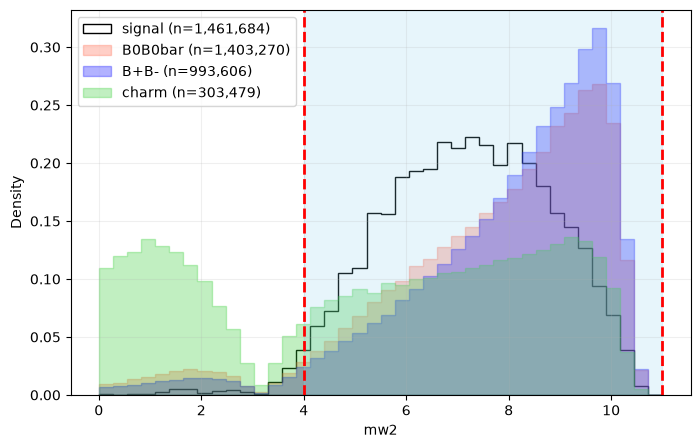

In [41]:
plotPreselection('mw2', [4,11], 40, (0,11))

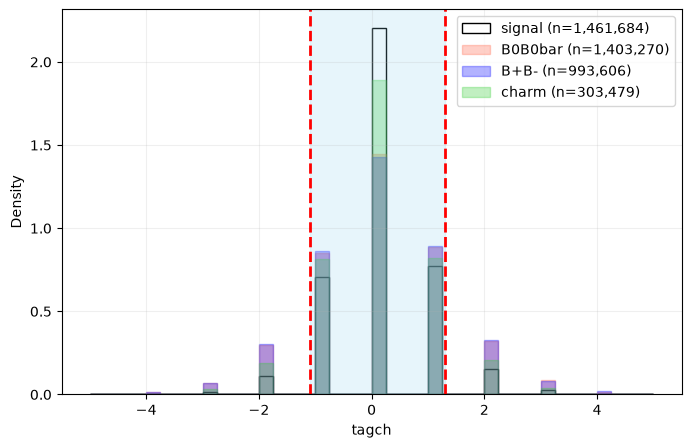

In [42]:
plotPreselection('tagch', [-1.1,1.3], 40, (-5,5))

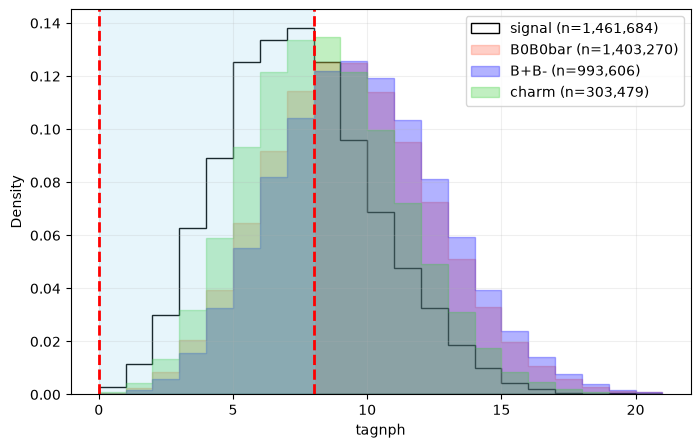

In [144]:
plotPreselection('tagnph', [0,8], 21, (0,21))

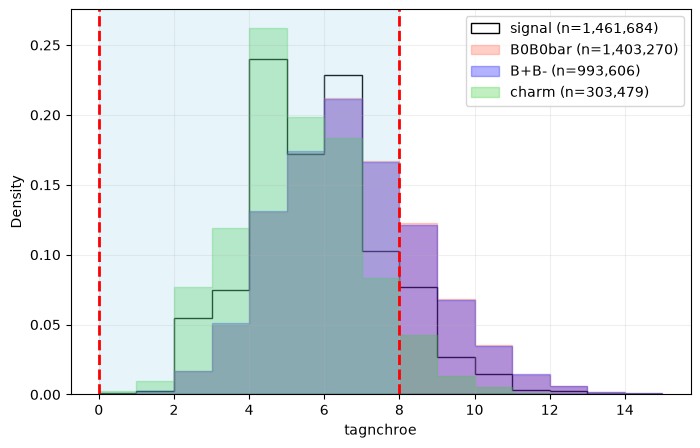

In [127]:
plotPreselection('tagnchroe', [0,8], 15, (0,15))

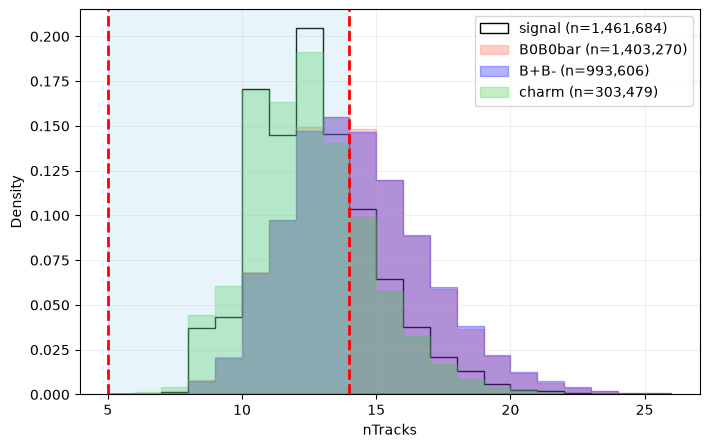

In [132]:
plotPreselection('nTracks', [5,14], 21, (5,26))

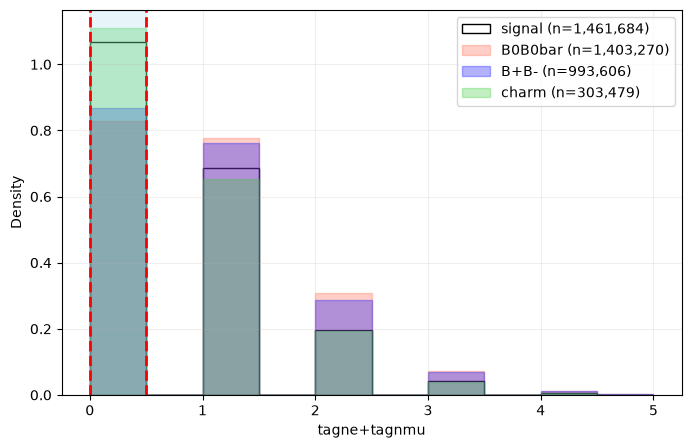

In [66]:
plotPreselection('tagne+tagnmu', [0.0, 0.5], 10, (0,5))

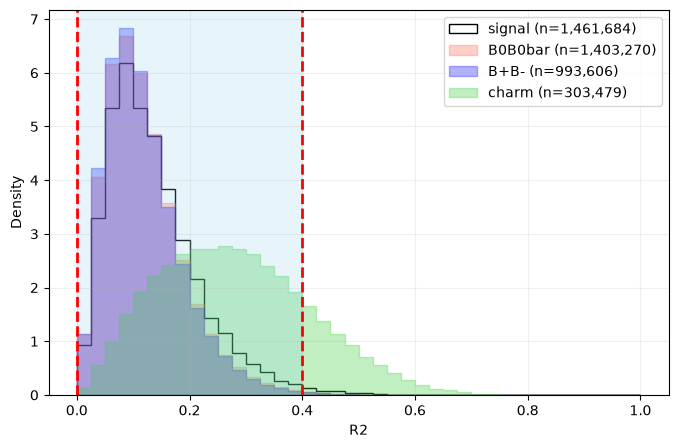

In [74]:
plotPreselection('R2', [0.0, 0.4], 40, (0,1))

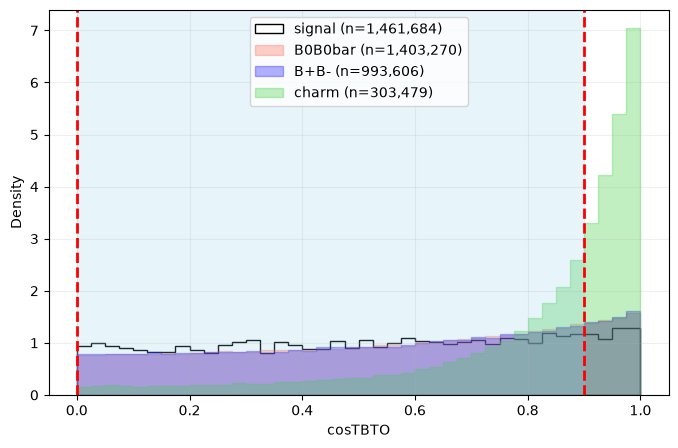

In [142]:
plotPreselection('cosTBTO', [0.0, 0.9], 40, (0,1))

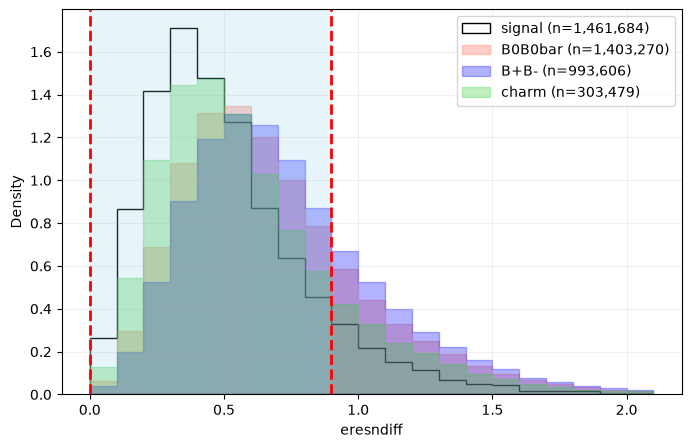

In [134]:
plotPreselection('eresndiff', [0,0.9], 21, (0,2.1))

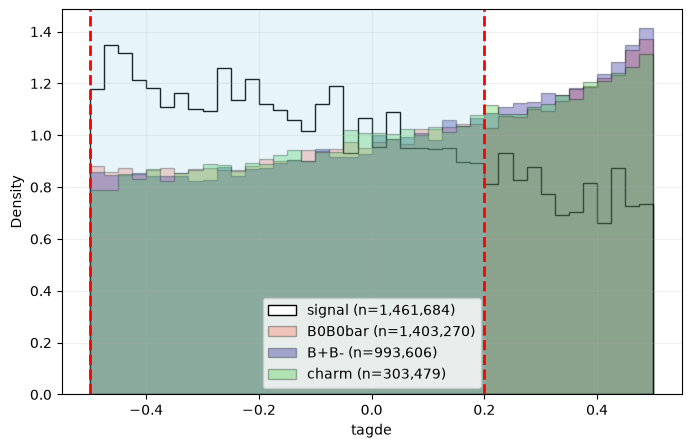

In [97]:
plotPreselection('tagde', [-0.5,0.2], 40, (-0.5,0.5))

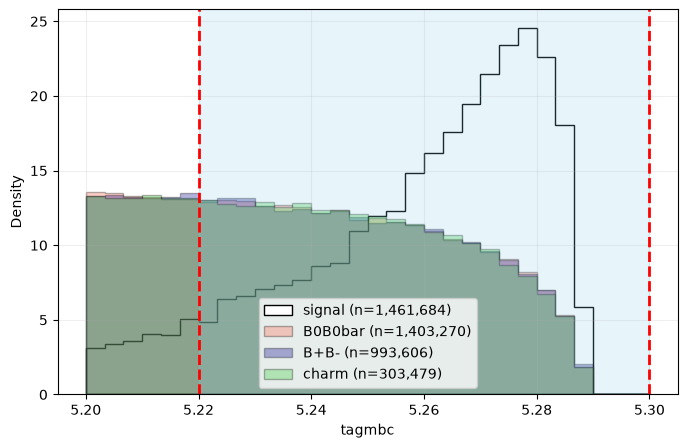

In [12]:
plotPreselection('tagmbc', [5.22,5.3], 30, (5.2,5.3))

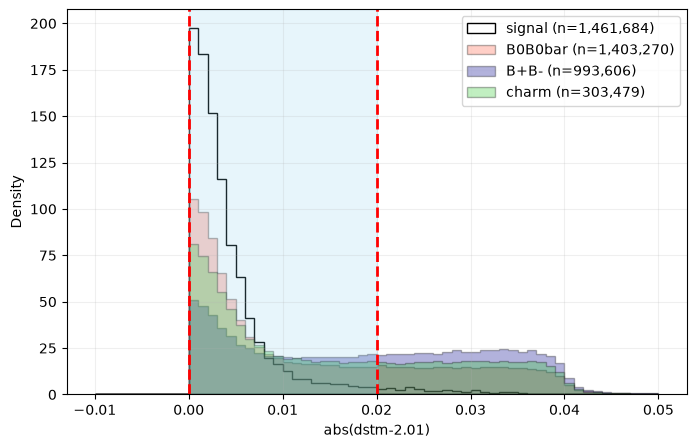

In [27]:
plotPreselection('abs(dstm-2.01)', [0.0,0.02], 60, (-0.01,0.05))

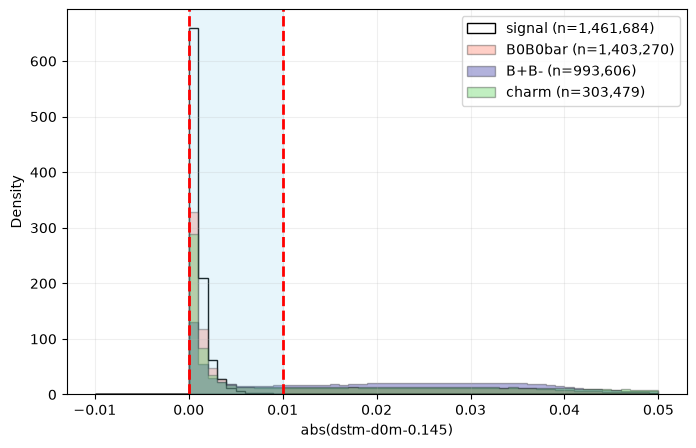

In [33]:
plotPreselection('abs(dstm-d0m-0.145)', [0.0,0.01], 60, (-0.01,0.05))

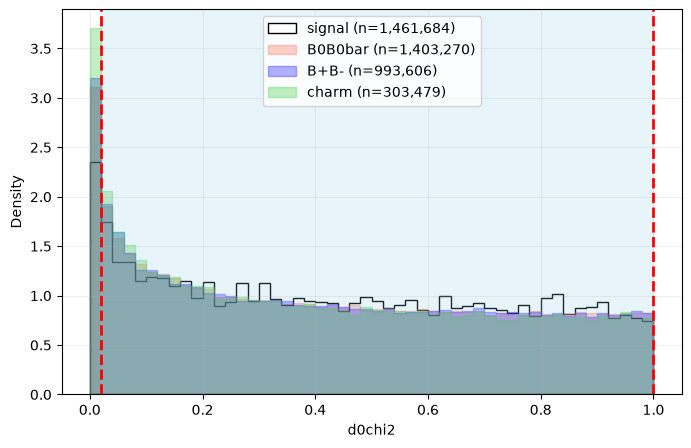

In [128]:
plotPreselection('d0chi2', [0.02, 1.0], 50, (0.0, 1.0))

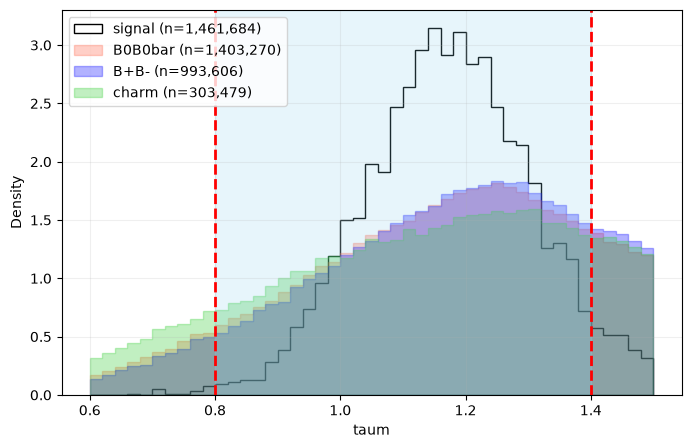

In [115]:
plotPreselection('taum', [0.8, 1.4], 45, (0.6,1.5))

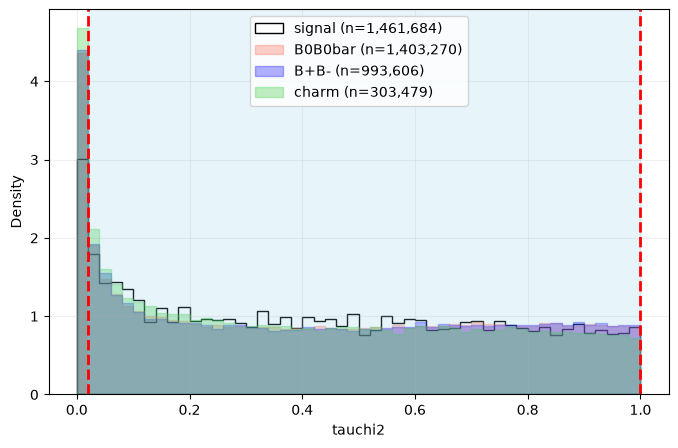

In [90]:
plotPreselection('tauchi2', [0.02, 1.0], 50, (0.0, 1.0))

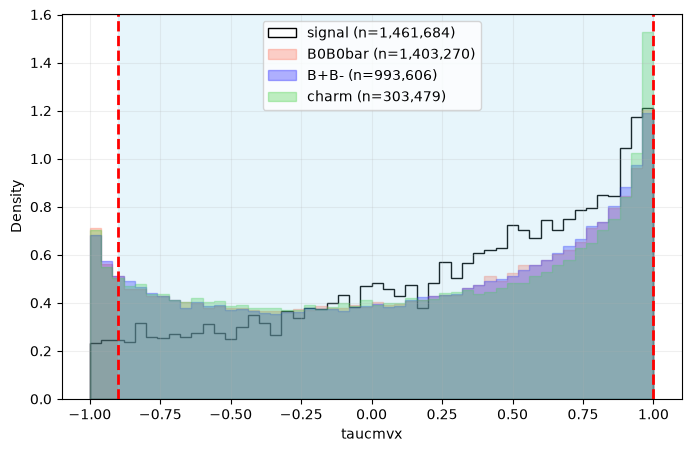

In [139]:
plotPreselection('taucmvx', [-0.9, 1.0], 50, (-1.0, 1.0))

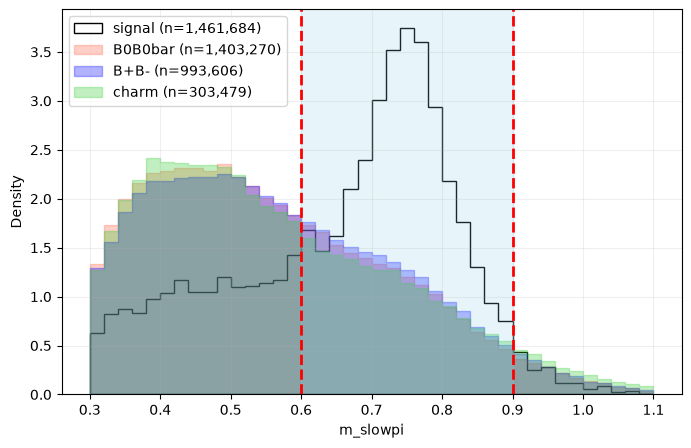

In [123]:
plotPreselection('m_slowpi', [0.60, 0.9], 40, (0.3, 1.1))

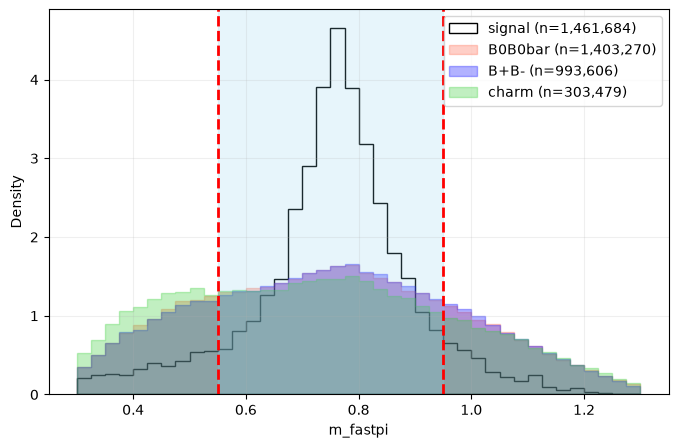

In [104]:
plotPreselection('m_fastpi', [0.55, 0.95], 40, (0.3, 1.3))

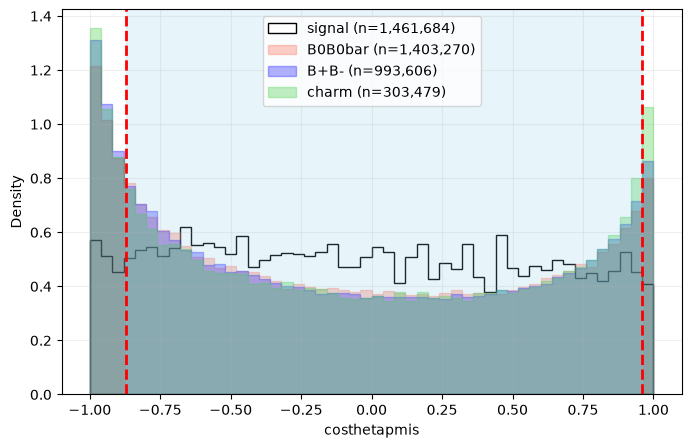

In [109]:
plotPreselection('costhetapmis', [-0.87, 0.96], 50, (-1.0, 1.0))

In [116]:

def plot_comparison_dynamic_range(df_sig, df_mix, df_ch, df_cc, features, 
                                  sig_cut=None, bg_cut=None, 
                                  bins=50, figsize=(15*2, 20*5), margin_frac=0.05):
    """
    Histograms with dynamic range for signal and 3 bkg components to compare shapes.
    Range (min,max) is estimated for each feature after applying cuts.
    
    Parameters:
    - df_sig, df_mix: DataFrames
    - features:
    - sig_cut: conditions (string to query or boolean mask).
    - bg_cut: ...
    - bins: 
    - figsize: total figure size
    - margin_frac: fraction added as margin to min/max range
    """
    
    n = len(features)
    if n == 0:
        print("no features")
        return
    else:
        print("# of features: ", n)

    rows = (n+10) // 4
    fig, axes = plt.subplots(rows, 4, figsize=figsize)
    axes = axes.flatten()

# Oblicz liczbę kolumn i wierszy (np. 6 kolumn lub pierwiastek z liczby cech)
#ncols = 6 
#nrows = math.ceil(n_features / ncols)

#fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize)

    

    # auxialary method to apply cuts
    def get_filtered_data(df, col, cut):
        if cut is None:
            data = df[col]
        elif isinstance(cut, str):
            try:
                data = df.query(cut)[col]
            except Exception as e:
                print(f"Error query '{cut}' for column {col}: {e}")
                return pd.Series([], dtype=float)
        elif isinstance(cut, pd.Series) and cut.dtype == bool:
            data = df.loc[cut, col]
        else:
            data = df[col]
            
        # remove nan? 
        return data.dropna()

    for i, col in enumerate(features):
        ax = axes[i]
        
        # 1. upload and filterout data 
        data_sig = get_filtered_data(df_sig, col, sig_cut)
        data_mix = get_filtered_data(df_mix, col, bg_cut)
        data_ch = get_filtered_data(df_ch, col, bg_cut)
        data_cc = get_filtered_data(df_cc, col, bg_cut)
        
        # check if no empty
        has_sig = len(data_sig) > 0
        has_mix = len(data_mix) > 0
        has_ch = len(data_ch) > 0
        has_cc = len(data_cc) > 0
        
        if not has_sig and not has_mix and not has_ch and not has_cc:
            ax.text(0.5, 0.5, "Lack of data\nafter cuts", ha='center', va='center', transform=ax.transAxes)
            ax.set_title(f"{col}", fontsize=20)
            ax.set_xlabel(col)
            ax.set_ylabel("N")
            continue

        # 2. dynamic range (MIN, MAX) 
        min_val = float('inf')
        max_val = float('-inf')
        
        if has_sig:
            min_val = min(min_val, data_sig.min())
            max_val = max(max_val, data_sig.max())
            
        if has_mix:
            min_val = min(min_val, data_mix.min())
            max_val = max(max_val, data_mix.max())
        
        if has_ch:
            min_val = min(min_val, data_ch.min())
            max_val = max(max_val, data_ch.max())
            
        if has_cc:
            min_val = min(min_val, data_cc.min())
            max_val = max(max_val, data_cc.max())    
        
        # add margin
        data_range = max_val - min_val
        if data_range == 0:
            margin = 0.1 # case if all values are the same 
        else:
            margin = data_range * margin_frac
            
        curr_range = (min_val - margin, max_val + margin)

        # 3. Drawing
        zorder_sig = 10
        zorder_mix = 5
        
        if has_sig:
            ax.hist(data_sig, bins=bins, range=curr_range,
                    color='white', edgecolor='black', linewidth=1.2,
                    alpha=0.5, label=f'Sig (n={len(data_sig):,})',
                    histtype='stepfilled', zorder=zorder_sig, density=False)
        
        if has_mix:
            ax.hist(data_mix, bins=bins, range=curr_range,
                    color='tomato', edgecolor='black', linewidth=1.0,
                    alpha=0.4, label=f'B0B0bar (n={len(data_mix):,})', 
                    histtype='stepfilled', zorder=zorder_mix, density=False)
        
        if has_ch:
            ax.hist(data_ch, bins=bins, range=curr_range,
                    color='darkblue', edgecolor='black', linewidth=1.0,
                    alpha=0.4, label=f'B+B- (n={len(data_ch):,})',
                    histtype='stepfilled', zorder=zorder_mix, density=False)

        if has_cc:
            ax.hist(data_cc, bins=bins, range=curr_range,
                    color='limegreen', edgecolor='black', linewidth=1.0,
                    alpha=0.4, label=f'charm (n={len(data_cc):,})',
                    histtype='stepfilled', zorder=zorder_mix, density=False)

        # decorations
        ax.set_title(f"{col}", fontsize=22, fontweight='bold')
        #ax.set_xlabel(col)
        ax.set_ylabel("N")
        ax.legend(loc='best', fontsize=18, frameon=True, facecolor='white', framealpha=0.8)
        ax.grid(axis='y', linestyle='--', alpha=0.3)

    # Remove empty subplots
    for j in range(n, len(axes)):
        fig.delaxes(axes[j])
        
    plt.tight_layout()
    plt.show()


In [117]:
print(np.cos(17*(3.14159265/180.0)))
  
print(np.cos(150*(3.14159265/180.0)))

0.95630475606216
-0.8660254022886916


preselection:  mw2 > 4 and abs(tagch) < 2 and tagnph < 8 and tagnchroe < 8 and nTracks<14 and tagne+tagnmu==0 and R2<0.4 and cosTBTO<0.9 and eresndiff < 0.9 and tagde < 0.2 and tagmbc>5.22 and abs(dstm-2.01)<0.02 and abs(dstm-d0m-0.145)<0.01 and d0chi2>0.02 and taum>0.8 and taum<1.4 and tauchi2>0.02 and taucmvx > -0.9 and m_slowpi>0.60 and m_slowpi<0.9 and m_fastpi>0.55 and m_fastpi<0.95 and costhetapmis>-0.87 and costhetapmis<0.96
# of features:  50


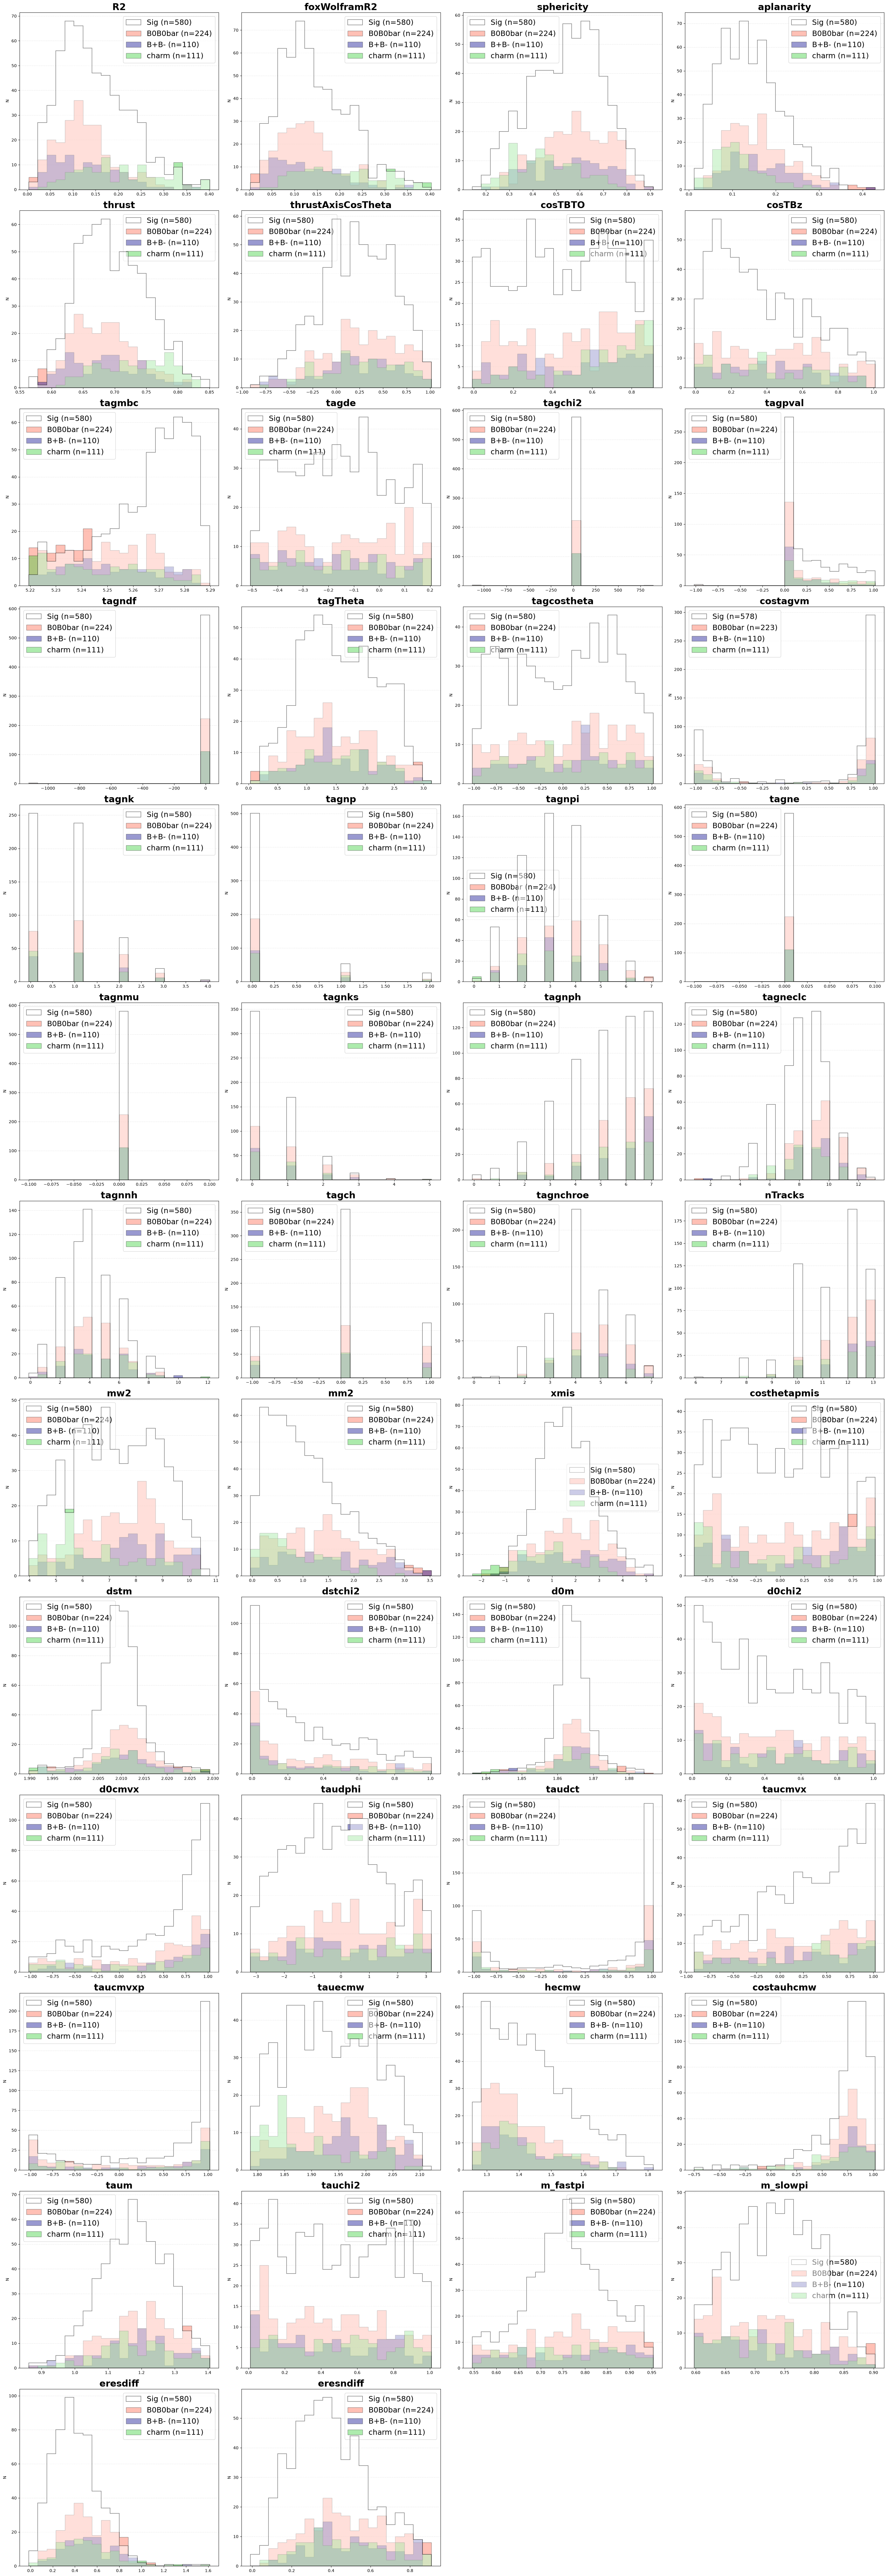

CPU times: user 16.4 s, sys: 38.5 ms, total: 16.4 s
Wall time: 16.9 s


In [143]:
%%time 


# Selection

cuts = [
'mw2 > 4',
'abs(tagch) < 2', 'tagnph < 8', 'tagnchroe < 8', 'nTracks<14',  
'tagne+tagnmu==0', 
'R2<0.4','cosTBTO<0.9',
'eresndiff < 0.9',
'tagde < 0.2', 'tagmbc>5.22',
'abs(dstm-2.01)<0.02','abs(dstm-d0m-0.145)<0.01', 'd0chi2>0.02',
'taum>0.8', 'taum<1.4', 'tauchi2>0.02', 'taucmvx > -0.9',
'm_slowpi>0.60', 'm_slowpi<0.9',  
'm_fastpi>0.55', 'm_fastpi<0.95',     
'costhetapmis>-0.87','costhetapmis<0.96'
]

cuts_string = " and ".join(cuts)
print('preselection: ', cuts_string)

cuts_sig = '(sigissig == 1)' + ' and ' + cuts_string 
cuts_bkg = '(sigissig != 1)' + ' and ' + cuts_string


# CDC acceptance: 
# 'costhetapmis>-0.86','costhetapmis<0.96' 
# 0.95630475606216, -0.8660254022886916





feats = [
'R2', 'foxWolframR2', 'sphericity', 'aplanarity', 'thrust', 'thrustAxisCosTheta', 'cosTBTO','cosTBz',
'tagmbc', 'tagde', 'tagchi2', 'tagpval', 'tagndf', 
'tagTheta', 'tagcostheta','costagvm',    
'tagnk', 'tagnp', 'tagnpi', 'tagne', 'tagnmu', 'tagnks',
'tagnph', 'tagneclc', 'tagnnh', 
'tagch', 'tagnchroe', 'nTracks',
'mw2', 'mm2', 'xmis', 'costhetapmis',
'dstm', 'dstchi2', 'd0m', 'd0chi2', 'd0cmvx', 
'taudphi','taudct',
'taucmvx', 'taucmvxp', 
'tauecmw', 'hecmw', 'costauhcmw',
'taum', 'tauchi2', 
'm_fastpi', 'm_slowpi',
'eresdiff', 'eresndiff',]


plot_comparison_dynamic_range(
    df_sig=dfsig_1, 
    df_mix=dfmix_1, 
    df_ch=dfch_1,
    df_cc=dfcc_1,
    features=feats,
    sig_cut=cuts_sig, 
    bg_cut=cuts_bkg, 
    bins=20,
    margin_frac=0.01  # 0.05% marginesu z każdej strony
)